In [1]:
import torch
import torchvision

In [1]:
import os
from pathlib import Path

data_path = "data/path"

for dirpath, dirname, files in os.walk(data_path):
    print(f"There are {len(dirname)} directories and {len(files)} files in {dirpath}")

data_path = Path(data_path)

In [3]:
train_path = data_path / "train"
test_path = data_path / "test"

train_path

PosixPath('/home/yasir/Desktop/2026/ML/Neural_Networks/rainbow_colors/train')

In [4]:
train_data_list = list(train_path.glob("*/*.jpg"))

len(train_data_list)

700

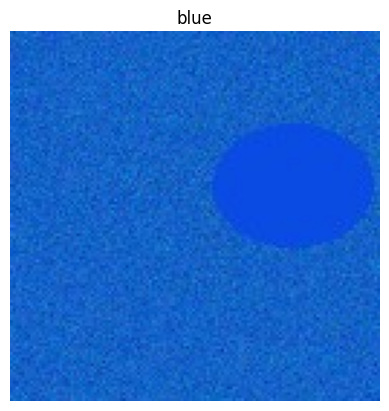

In [5]:
from PIL import Image
import matplotlib.pyplot as plt
import random

random.seed(42)
random_img = random.choice(train_data_list)

img_class = random_img.parent.stem

with Image.open(random_img) as img:
    plt.imshow(img)
    plt.title(img_class)
    plt.axis(False)


In [6]:
import numpy as np 

img_as_arr = np.asarray(img)
img_as_arr.shape

(128, 128, 3)

In [7]:
from torchvision import transforms

data_transform = transforms.Compose([transforms.Resize(size=(64, 64)),
                                     transforms.RandomHorizontalFlip(0.5),
                                     transforms.ToTensor()])

data_transform

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
)

In [8]:
transformed_img = data_transform(img)
print(f"Before Trasform {img_as_arr.shape}\nAfter Transform{transformed_img.shape}")

Before Trasform (128, 128, 3)
After Transformtorch.Size([3, 64, 64])


In [9]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(root=train_path,
                                     transform=data_transform)

test_dataset = datasets.ImageFolder(root=test_path,
                                    transform=data_transform)

train_dataset

Dataset ImageFolder
    Number of datapoints: 700
    Root location: /home/yasir/Desktop/2026/ML/Neural_Networks/rainbow_colors/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )

In [10]:
classes = train_dataset.classes
len(train_dataset) , len(test_dataset)

(700, 175)

In [11]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

train_dataloader

In [12]:
image , label = next(iter(train_dataloader))

image.shape

torch.Size([32, 3, 64, 64])

In [13]:
from torch import nn

torch.manual_seed(42)

class TinyVGG(nn.Module):
    def __init__(self, input_shape=3, hidden_units=10, output_shape=7):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),  
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=(hidden_units * 256), out_features=output_shape)   
        )

    def forward(self, x):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))
        
model = TinyVGG()

In [14]:
# Untrained Predictions

x, y = next(iter(train_dataloader))

x1 = model(x)

# Softmax (per-sample)
x1_probs = torch.softmax(x1, dim=1)

# Get predicted classes
z = torch.argmax(x1_probs, dim=1)

print(f"Predictions: {z}")
print(f"Labels: {y}")
print(f"Correct predictions: {(z == y).sum().item()} / {len(y)}")

Predictions: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0,
        5, 0, 0, 0, 0, 0, 0, 0])
Labels: tensor([0, 4, 3, 2, 0, 0, 5, 1, 5, 5, 3, 5, 5, 5, 1, 4, 6, 3, 5, 0, 1, 0, 4, 2,
        0, 3, 6, 6, 3, 3, 4, 1])
Correct predictions: 4 / 32


In [15]:
from torchinfo import summary
summary(model , input_size=(32,3,64,64))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 7]                   --
├─Sequential: 1-1                        [32, 10, 32, 32]          --
│    └─Conv2d: 2-1                       [32, 10, 64, 64]          280
│    └─ReLU: 2-2                         [32, 10, 64, 64]          --
│    └─Conv2d: 2-3                       [32, 10, 64, 64]          910
│    └─ReLU: 2-4                         [32, 10, 64, 64]          --
│    └─MaxPool2d: 2-5                    [32, 10, 32, 32]          --
├─Sequential: 1-2                        [32, 10, 16, 16]          --
│    └─Conv2d: 2-6                       [32, 10, 32, 32]          910
│    └─ReLU: 2-7                         [32, 10, 32, 32]          --
│    └─Conv2d: 2-8                       [32, 10, 32, 32]          910
│    └─ReLU: 2-9                         [32, 10, 32, 32]          --
│    └─MaxPool2d: 2-10                   [32, 10, 16, 16]          --
├─Sequentia

In [16]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [17]:
Epochs = 10

# Training 
for epoch in range(Epochs):
    model.train()

    train_loss, train_acc = 0, 0
    for x, y in train_dataloader:
        y_pred = model(x)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(y_pred, dim=1)
        train_acc += (y_pred_class == y).sum().item()

    train_loss = train_loss / len(train_dataloader)
    train_acc = (train_acc / len(train_dataset)) * 100

    # Testing
    model.eval()
    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for x, y in test_dataloader:
            test_pred = model(x)

            loss = loss_fn(test_pred, y)
            test_loss += loss.item()

            test_pred_labels = test_pred.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item()

    test_loss = test_loss / len(test_dataloader)
    test_acc = (test_acc / len(test_dataset)) * 100

    print(f"Epoch {epoch +1} | Train Loss {train_loss:.4f} | Train Accuracy {train_acc:.2f}% | Test Loss {test_loss:.4f} | Test Accuracy {test_acc:.2f}%")

Epoch 1 | Train Loss 1.7791 | Train Accuracy 20.86% | Test Loss 1.3097 | Test Accuracy 32.57%
Epoch 2 | Train Loss 1.0671 | Train Accuracy 47.29% | Test Loss 0.8198 | Test Accuracy 57.14%
Epoch 3 | Train Loss 0.5879 | Train Accuracy 75.71% | Test Loss 0.2153 | Test Accuracy 96.57%
Epoch 4 | Train Loss 0.0801 | Train Accuracy 98.71% | Test Loss 0.0099 | Test Accuracy 100.00%
Epoch 5 | Train Loss 0.0189 | Train Accuracy 99.86% | Test Loss 0.0525 | Test Accuracy 98.29%
Epoch 6 | Train Loss 0.0259 | Train Accuracy 99.00% | Test Loss 0.0048 | Test Accuracy 100.00%
Epoch 7 | Train Loss 0.0086 | Train Accuracy 100.00% | Test Loss 0.0223 | Test Accuracy 99.43%
Epoch 8 | Train Loss 0.0061 | Train Accuracy 100.00% | Test Loss 0.0045 | Test Accuracy 100.00%
Epoch 9 | Train Loss 0.0065 | Train Accuracy 99.86% | Test Loss 0.0813 | Test Accuracy 97.14%
Epoch 10 | Train Loss 0.0581 | Train Accuracy 98.14% | Test Loss 0.0393 | Test Accuracy 98.29%


In [18]:
x, y = next(iter(train_dataloader))

x1 = model(x)

# Softmax on dim=1 (per-sample)
x1_probs = torch.softmax(x1, dim=1)

# Get predicted classes
z = torch.argmax(x1_probs, dim=1)

print(f"Predictions: {z}")
print(f"Labels: {y}")
print(f"Correct predictions: {(z == y).sum().item()} / {len(y)}")

Predictions: tensor([6, 0, 0, 1, 1, 4, 1, 3, 6, 4, 3, 2, 3, 0, 1, 4, 5, 1, 6, 5, 5, 1, 5, 1,
        1, 5, 3, 6, 4, 4, 5, 4])
Labels: tensor([6, 0, 0, 1, 1, 4, 1, 3, 3, 4, 3, 2, 3, 0, 1, 4, 5, 1, 6, 5, 5, 1, 5, 1,
        1, 5, 3, 6, 4, 4, 5, 4])
Correct predictions: 31 / 32
